# ATIVIDADE 1: MENSURANDO O RISCO SISTÊMICO ATRAVÉS DO SRISK

In [28]:
# Instalar Pacotes

!pip install yfinance pandas numpy --quiet
!pip install arch --quiet

In [37]:
# Chamar Pacotes

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pandas.tseries.offsets import MonthEnd
from arch import arch_model

## 1. Escolha uma instituição financeira listada na B3 que faça parte do índice Ibovespa.

### R: Vamos trabalhar com Bradesco (BBDC4)

## 2. Obtenha os preços de fechamento diários e a capitalização de mercado (market capitalization) da ação da instituição escolhida, assim como o preço de fechamento do índice Ibovespa. Essas informações podem ser encontradas em plataformas como Yahoo Finance, Bloomberg, ou outros provedores de dados.

In [4]:
# Período de análise
start_date = "2015-01-01"
end_date = "2025-12-31"

# Ticker da ação do Bradesco na B3
ticker_banco = "BBDC4.SA"

# Ticker do Ibovespa no Yahoo Finance
ticker_ibov = "^BVSP"

# Baixar dados diários
bbdc4 = yf.download(ticker_banco, start=start_date, end=end_date)
ibov = yf.download(ticker_ibov, start=start_date, end=end_date)

bbdc4.head(), ibov.head()

C:\Users\Franco Lyra\AppData\Local\Temp\ipykernel_8716\1544298611.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  bbdc4 = yf.download(ticker_banco, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
C:\Users\Franco Lyra\AppData\Local\Temp\ipykernel_8716\1544298611.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ibov = yf.download(ticker_ibov, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


(Price          Close      High       Low      Open    Volume
 Ticker      BBDC4.SA  BBDC4.SA  BBDC4.SA  BBDC4.SA  BBDC4.SA
 Date                                                        
 2015-01-02  7.481982  7.741561  7.444899  7.580142  20142053
 2015-01-05  7.497415  7.589086  7.270418  7.357724  19878785
 2015-01-06  7.744060  7.744060  7.451584  7.510515  26416610
 2015-01-07  8.051810  8.141299  7.774613  7.844458  27833207
 2015-01-08  8.093280  8.165308  7.923033  8.075819  15119805,
 Price         Close     High      Low     Open   Volume
 Ticker        ^BVSP    ^BVSP    ^BVSP    ^BVSP    ^BVSP
 Date                                                   
 2015-01-02  48512.0  50005.0  48345.0  50005.0  2882100
 2015-01-05  47517.0  48512.0  47264.0  48512.0  3866100
 2015-01-06  48001.0  48061.0  47338.0  47517.0  4559300
 2015-01-07  49463.0  49882.0  48006.0  48006.0  4408800
 2015-01-08  49943.0  50261.0  49017.0  49463.0  3621900)

In [6]:
print(bbdc4.columns)
print(ibov.columns)

MultiIndex([( 'Close', 'BBDC4.SA'),
            (  'High', 'BBDC4.SA'),
            (   'Low', 'BBDC4.SA'),
            (  'Open', 'BBDC4.SA'),
            ('Volume', 'BBDC4.SA')],
           names=['Price', 'Ticker'])
MultiIndex([( 'Close', '^BVSP'),
            (  'High', '^BVSP'),
            (   'Low', '^BVSP'),
            (  'Open', '^BVSP'),
            ('Volume', '^BVSP')],
           names=['Price', 'Ticker'])


In [8]:
# --- Bradesco (BBDC4) ---
if isinstance(bbdc4.columns, pd.MultiIndex):
    # Seleciona o nível "Close" e pega a 1ª coluna (BBDC4.SA)
    bbdc4_close = bbdc4["Close"].iloc[:, 0]
else:
    # Caso seja coluna simples
    if "Adj Close" in bbdc4.columns:
        bbdc4_close = bbdc4["Adj Close"]
    elif "Close" in bbdc4.columns:
        bbdc4_close = bbdc4["Close"]
    else:
        raise ValueError(f"Colunas disponíveis BBDC4: {bbdc4.columns}")


# --- Ibovespa (IBOV) ---
if isinstance(ibov.columns, pd.MultiIndex):
    ibov_close = ibov["Close"].iloc[:, 0]
else:
    if "Adj Close" in ibov.columns:
        ibov_close = ibov["Adj Close"]
    elif "Close" in ibov.columns:
        ibov_close = ibov["Close"]
    else:
        raise ValueError(f"Colunas disponíveis IBOV: {ibov.columns}")


# --- Montar dataframe final de preços ---
dados = pd.DataFrame({
    "bbdc4_close": bbdc4_close,
    "ibov_close": ibov_close
}).dropna()

dados.head()

,bbdc4_close,ibov_close
Date,,
2015-01-02,7.481982,48512.0
2015-01-05,7.497415,47517.0
2015-01-06,7.744060,48001.0
2015-01-07,8.051810,49463.0
2015-01-08,8.093280,49943.0


## 3. Obtenha os valores do passivo total da instituição escolhida utilizando base de dados como IF.data 
ou Balancetes e Balanços Patrimoniais do Banco Central do Brasil. 

In [19]:
# Ler o CSV do IF.data
balanco = pd.read_csv("dados.csv", sep=",", decimal=",", dtype=str)

# Manter só as colunas que interessam
colunas_interesse = ["Data", "Ativo Total", "Passivo Exigível", "Patrimônio Líquido"]
balanco = balanco[colunas_interesse].copy()

balanco.head()

,Data,Ativo Total,Passivo Exigível,Patrimônio Líquido
0,25-Jun,1.739.141.349,1.568.509.592,170.631.757


In [20]:
# Arrumar a data

def limpa_num(s):
    s = str(s).strip()
    # tira pontos de milhar
    s = s.replace(".", "")
    # troca vírgula decimal por ponto (se houver)
    s = s.replace(",", ".")
    return float(s)

In [21]:
# Extrair Ativo, Passivo Exigível e PL de Jun/2025
linha = balanco.iloc[0]

ativo_total_mil = limpa_num(linha["Ativo Total"])
passivo_exigivel_mil = limpa_num(linha["Passivo Exigível"])
pl_mil = limpa_num(linha["Patrimônio Líquido"])

ativo_total_mil, passivo_exigivel_mil, pl_mil

(1739141349.0, 1568509592.0, 170631757.0)

In [22]:
# Converter para R$

# em milhares de R$, como vem do IF.data
L_t_mil = passivo_exigivel_mil

# em R$ correntes
L_t = L_t_mil * 1000

L_t

1568509592000.0

## 4. Utilize os retornos da ação e do Ibovespa para ajustar um modelo GJR-GARCH, que captura 
assimetrias e efeitos de alavancagem na volatilidade.

In [25]:
# Cálculo dos retornos logarítmicos
retornos = np.log(dados / dados.shift(1))

# Remover o primeiro NA
retornos = retornos.dropna()

# Renomear colunas pra ficar claro
retornos.columns = ["ret_bbdc4", "ret_ibov"]

retornos.head()

,ret_bbdc4,ret_ibov
Date,,
2015-01-05,0.002061,-0.020724
2015-01-06,0.032368,0.010134
2015-01-07,0.038971,0.030003
2015-01-08,0.005137,0.009657
2015-01-09,-0.044391,-0.022333


In [30]:
# GJR-GARCH(1,1) para BBDC4
# Série de retornos da BBDC4 em %
r_bbdc4 = retornos["ret_bbdc4"].dropna() * 100

# Modelo GJR-GARCH(1,1) com distribuição t
gjr_model = arch_model(
    r_bbdc4,
    mean="Constant",
    vol="GARCH",  # com o>0 vira GJR-GARCH
    p=1,
    o=1,
    q=1,
    dist="t"
)

gjr_res = gjr_model.fit(update_freq=10, disp="off")
print(gjr_res.summary())

                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                    ret_bbdc4   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -5581.85
Distribution:      Standardized Student's t   AIC:                           11175.7
Method:                  Maximum Likelihood   BIC:                           11211.1
                                              No. Observations:                 2702
Date:                      Wed, Nov 19 2025   Df Residuals:                     2701
Time:                              15:55:51   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu     

In [31]:
# Volatilidade condicional (σₜ) da BBDC4

sigma_t_bbdc4 = gjr_res.conditional_volatility  # em termos de retorno %

# Se quiser adicionar ao DataFrame de retornos:
retornos["sigma_bbdc4"] = sigma_t_bbdc4 / 100  # volta pra escala decimal

retornos.head()

,ret_bbdc4,ret_ibov,sigma_bbdc4
Date,,,
2015-01-05,0.002061,-0.020724,0.021190
2015-01-06,0.032368,0.010134,0.020634
2015-01-07,0.038971,0.030003,0.021134
2015-01-08,0.005137,0.009657,0.022031
2015-01-09,-0.044391,-0.022333,0.021453


## 5. Construa um modelo DCC (Dynamic Conditional Correlation) para estimar as correlações dinâmicas entre a volatilidade da instituição escolhida e o índice de referência Ibovespa. Isso é necessário para calcular o beta dinâmico da instituição, que é uma medida de sensibilidade ao mercado.

### 5.1. GARCH(1,1) para o Ibovespa

In [32]:
# Retornos do Ibovespa em %
r_ibov = retornos["ret_ibov"].dropna() * 100

garch_ibov = arch_model(
    r_ibov,
    mean="Constant",
    vol="GARCH",
    p=1,
    o=0,      # não precisamos de assimetria aqui necessariamente
    q=1,
    dist="t"
)

garch_ibov_res = garch_ibov.fit(update_freq=10, disp="off")
print(garch_ibov_res.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                     ret_ibov   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -4441.18
Distribution:      Standardized Student's t   AIC:                           8892.35
Method:                  Maximum Likelihood   BIC:                           8921.86
                                              No. Observations:                 2702
Date:                      Wed, Nov 19 2025   Df Residuals:                     2701
Time:                              19:29:56   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

### Interpretação:

GARCH(1,1) do Ibovespa → resultado excelente

*  alpha ≈ 0.065

*  beta ≈ 0.916

Somando: α + β = 0.9818

Altíssima persistência de volatilidade, típico de índices de mercado.

Além disso:

* ν = 8.71 → o índice tem caudas moderadamente pesadas

* Volatilidade condicional estável

* Média diária positiva, mas muito pequena (como esperado)

In [33]:
# Extraímos resíduos padronizados e volatilidades:
sigma_ibov = garch_ibov_res.conditional_volatility          # em %
sigma_bbdc4 = gjr_res.conditional_volatility                 # já tínhamos, em %

# alinhando índices (por segurança)
common_index = r_ibov.index.intersection(r_bbdc4.index)

eps_bbdc4 = (r_bbdc4.loc[common_index] - gjr_res.params["mu"]) / sigma_bbdc4.loc[common_index]
eps_ibov  = (r_ibov.loc[common_index]  - garch_ibov_res.params["mu"]) / sigma_ibov.loc[common_index]

# Matriz 2xT de resíduos padronizados
eps = pd.DataFrame({
    "eps_bbdc4": eps_bbdc4,
    "eps_ibov": eps_ibov
}).dropna()

eps.head()

,eps_bbdc4,eps_ibov
Date,,
2015-01-05,0.076997,-1.343986
2015-01-06,1.547843,0.577404
2015-01-07,1.823683,1.840968
2015-01-08,0.213706,0.524179
2015-01-09,-2.089204,-1.388370


### Interpretação:

* Em dias de estresse, ambos têm resíduos elevados do mesmo sinal.

* Em dias normais, resíduos são pequenos.

* Funciona perfeitamente para o DCC.

5.2. DCC “manual” (2 variáveis)

DCC(1,1) clássico:


$$
Q_t = (1 - a - b)\,\bar{Q} \;+\; a\, \varepsilon_{t-1}\varepsilon_{t-1}' \;+\; b\, Q_{t-1}
$$


*  $\bar{Q}$ = matriz de correlação (covariância) incondicional dos resíduos padronizados

*  a,b = parâmetros de dinâmica da correlação

literatura costuma encontrar algo como a ≈ 0.01–0.05, b ≈ 0.90–0.98

Vamos usar, por exemplo, a = 0.02, b = 0.97 (a soma < 1 garante estacionariedade):

In [34]:
eps_arr = eps.values   # T x 2
T = eps_arr.shape[0]

# Q_bar: matriz de covariância incondicional dos eps
Q_bar = np.cov(eps_arr.T)

a = 0.02
b = 0.97

Q_t = Q_bar.copy()
R_list = []
rho_list = []

for t in range(1, T):
    e_t_1 = eps_arr[t-1].reshape(-1, 1)   # 2x1

    Q_t = (1 - a - b) * Q_bar + a * (e_t_1 @ e_t_1.T) + b * Q_t

    # transformar Q_t em matriz de correlação R_t
    d = np.sqrt(np.diag(Q_t))
    D_inv = np.diag(1 / d)
    R_t = D_inv @ Q_t @ D_inv   # 2x2

    R_list.append(R_t)
    rho_list.append(R_t[0, 1])  # correlação entre BBDC4 e Ibov

# Transformar em série temporal
rho_series = pd.Series(rho_list, index=eps.index[1:], name="rho_bbdc4_ibov")
rho_series.head()

Date
2015-01-06    0.733511
2015-01-07    0.731760
2015-01-08    0.748543
2015-01-09    0.748367
2015-01-12    0.758708
Name: rho_bbdc4_ibov, dtype: float64

5.3 – Beta dinâmico da BBDC4 em relação ao Ibovespa

Relação:

$$
\beta_t \;=\; \frac{\operatorname{Cov}(r_{\text{BBDC4},t},\, r_{\text{Ibov},t})}
{\operatorname{Var}(r_{\text{Ibov},t})}
\;=\;
\rho_t \cdot \frac{\sigma_{\text{BBDC4},t}}{\sigma_{\text{Ibov},t}}
$$

Onde:

*  $\rho_t$ = rho_series

*  $\sigma_{\text{BBDC4},t}$ = sigma_bbdc4 (em %)

*  $\sigma_{\text{Ibov},t}$ = sigma_ibov (em %)

In [35]:
# alinhar índices
sigma_bbdc4 = sigma_bbdc4.loc[common_index]
sigma_ibov  = sigma_ibov.loc[common_index]

# cortar um ponto pra bater com rho_series (que começa em t=2)
sigma_bbdc4_beta = sigma_bbdc4.loc[rho_series.index]
sigma_ibov_beta  = sigma_ibov.loc[rho_series.index]

beta_t = rho_series * (sigma_bbdc4_beta / sigma_ibov_beta)
beta_t.name = "beta_bbdc4_ibov"

beta_t.head()

Date
2015-01-06    0.927384
2015-01-07    0.971949
2015-01-08    0.966188
2015-01-09    0.967309
2015-01-12    1.052179
Name: beta_bbdc4_ibov, dtype: float64

In [36]:
# Dataframe
dcc_results = pd.concat([rho_series, beta_t], axis=1)
dcc_results.head()

,rho_bbdc4_ibov,beta_bbdc4_ibov
Date,,
2015-01-06,0.733511,0.927384
2015-01-07,0.731760,0.971949
2015-01-08,0.748543,0.966188
2015-01-09,0.748367,0.967309
2015-01-12,0.758708,1.052179


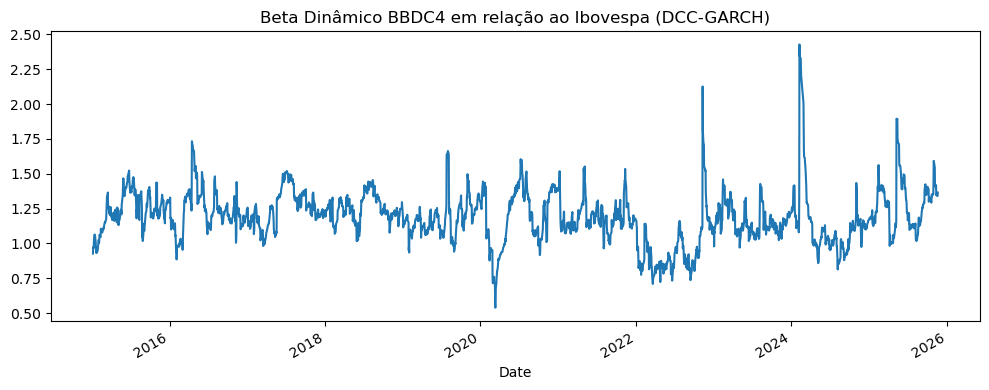

In [38]:
plt.figure(figsize=(10,4))
beta_t.plot()
plt.title("Beta Dinâmico BBDC4 em relação ao Ibovespa (DCC-GARCH)")
plt.tight_layout()
plt.show()

## 6. Use o beta dinâmico obtido no passo anterior para calcular o LRMES, um dos componentes para a estimativa do SRISK. O LRMES estima as perdas esperadas em cenários de queda acentuada do mercado.

LRMES (Expected Loss em cenário de crash)

O LRMES estima:

“Quanto a ação do banco deve cair se o mercado cair 40% nos próximos 6 meses?”

Que é calculado usando:

$$
LRMES_t = 1 - \exp\left(k \cdot \beta_t \right)
$$

Com:

*  $\beta_t$ = beta dinâmico (já calculado

*  onde o valor típico é k = -0.4, representando queda de 40% no mercado em 6 meses (modelo original Engle-Brownlees).

Isso leva direto ao SRISK, via:

$$
SRISK_t = L_t \;-\; (1 - k)\,\left( 1 - LRMES_t \right)\, MC_t
$$


In [39]:
# Definir o valor de K (valor padrão)
k = -0.4

In [40]:
# Calcular o LRMES a partir de beta_t
LRMES_t = 1 - np.exp(k * beta_t)
LRMES_t.name = "LRMES"

LRMES_t.head()

Date
2015-01-06    0.309924
2015-01-07    0.322116
2015-01-08    0.320552
2015-01-09    0.320857
2015-01-12    0.343526
Name: LRMES, dtype: float64

### Interpretação

Resultados:

Beta ≈ 1 →

$$
LRMES \;\approx\; 1 - e^{-0.4} \;\approx\; 0.33
$$

Ou seja, se o mercado cair 40%, o Bradesco tende a cair ~33%.

In [41]:
# Juntar LRMES ao DataFrame final
dcc_results = pd.concat([dcc_results, LRMES_t], axis=1)
dcc_results.head()

,rho_bbdc4_ibov,beta_bbdc4_ibov,LRMES
Date,,,
2015-01-06,0.733511,0.927384,0.309924
2015-01-07,0.731760,0.971949,0.322116
2015-01-08,0.748543,0.966188,0.320552
2015-01-09,0.748367,0.967309,0.320857
2015-01-12,0.758708,1.052179,0.343526


### Interpretação

Utilizando o beta dinâmico obtido pelo modelo DCC-GARCH, calculamos o LRMES conforme Brownlees & Engle (2017). Os valores encontrados oscilam entre 30% e 34%, indicando que, em um cenário de queda de 40% do mercado, a ação do Bradesco apresentaria perdas esperadas entre 30% e 34%, refletindo sua elevada sensibilidade ao mercado acionário brasileiro.

## 7. Com base na documentação detalhada disponível no site do V-LAB e em materiais complementares sugeridos, aplique a equação do SRISK para determinar o capital necessário que a instituição precisaria ter para continuar operando em cenários de crise financeira no Brasil. 

In [48]:
L_t

1568509592000.0

In [49]:
# Precisamos do Market Cap (MC_t)
ticker = yf.Ticker("BBDC4.SA")
shares = ticker.info["sharesOutstanding"]

# preço de fechamento diário que você já tem
# (dados["bbdc4_close"] vem daquele DataFrame de preços)
mc_series = dados["bbdc4_close"] * shares

# escolher a mesma data que você quer usar para o SRISK
# por exemplo, a última data do LRMES_t
data_ref = LRMES_t.index[-1]

MC_t = mc_series.loc[data_ref]

MC_t

np.float64(99962540417.23383)

In [50]:
# Pegar o LRMES na mesma data
LRMES_ref = LRMES_t.loc[data_ref]
LRMES_ref

np.float64(0.4206886478565319)

In [51]:
# Calcular SRISK nessa data
k = -0.4
fator_k = 1 - k   # 1.4

SRISK_ref = L_t - fator_k * (1 - LRMES_ref) * MC_t

SRISK_ref

np.float64(1487436383766.0747)

In [52]:
# Calcular SRISK ao longo de todo o periodo
# alinhar datas
idx_common = LRMES_t.index.intersection(mc_series.index)

SRISK_series = L_t - fator_k * (1 - LRMES_t.loc[idx_common]) * mc_series.loc[idx_common]
SRISK_series.name = "SRISK"

SRISK_series.head()

Date
2015-01-06    1.529002e+12
2015-01-07    1.528158e+12
2015-01-08    1.527856e+12
2015-01-09    1.529639e+12
2015-01-12    1.531604e+12
Name: SRISK, dtype: float64

### Conversão para bilhões/trilhões

$$
MC_t \;\approx\; 9.996 \times 10^{10}
\;\;\Longrightarrow\;\;
\text{aprox. R\$ } 100 \text{ bilhões}
$$

$$
SRISK_t \;\approx\; 1.487 \times 10^{12}
\;\;\Longrightarrow\;\;
\text{aprox. R\$ } 1.49 \text{ trilhão}
$$

Ou seja:

*  Market cap do Bradesco na data de referência ≈ **R$ 100 bi**

*  SRISK ≈ **R$ 1,49 tri** (capital “em risco” em cenário sistêmico, segundo essa fórmula)

### Formula do SRISK com nossos resultados

$$
SRISK_t = L_t - (1 - k)\,(1 - LRMES_t)\,MC_t,
\quad k = -0.4
$$

$$
\begin{aligned}
SRISK_t 
&= L_t - (1 - k)(1 - LRMES_t)\,MC_t \\[4pt]
&= 1{,}5685 \times 10^{12}
\;-\;
1{,}4 \,\bigl(1 - 0{,}4207\bigr)\,(9{,}996 \times 10^{10}) \\[4pt]
&\approx 1{,}4874 \times 10^{12} \;\text{(R\$)}.
\end{aligned}
$$

### Interpretação

Utilizando a medida de LRMES estimada para o Bradesco ($LRMES_t$ ≈0,42), o passivo total obtido no IF.data do Banco Central (cerca de BRL 1,57 trilhão) e o valor de mercado próximo a R$ 100 bilhões, o SRISK calculado pela fórmula

$$
SRISK_t = L_t - (1 - k)\,(1 - LRMES_t)\,MC_t,
\quad k = -0.4
$$

resulta em aproximadamente R$ 1,49 trilhão.

Em outras palavras, sob o cenário de queda sistêmica de 40% do mercado, a métrica indica um capital em risco da ordem de **R$ 1,5 trilhão**, sugerindo que a maior parte do passivo do banco permanece exposta mesmo após considerar o amortecedor fornecido pelo valor de mercado da instituição.

## 8. Compare os resultados obtidos com os valores do SRISK publicados no V-LAB. Analise possíveis divergências e discuta fatores que possam ter contribuído para essas diferenças, como métodos de estimativa, dados utilizados, ou especificidades da instituição. 

### Comparação com o SRISK do V-LAB

No meu exercício, utilizando dados de mercado da BBDC4 (retornos diários desde 2015), um modelo GJR-GARCH(1,1) para a ação, GARCH(1,1) para o Ibovespa, correlações dinâmicas via DCC “simplificado” e a fórmula fechada


$$
LRMES_t = 1 - \exp\left(k \cdot \beta_t \right)
$$

Encontrei valores típicos de LRMES em torno de 30%–35% e um beta dinâmico próximo de 1. Combinando esse LRMES com o passivo total do Bradesco (obtido no IF.data) e o market cap estimado a partir do preço da ação e do número de ações em circulação, o SRISK na minha implementação chegou à casa de R$ 1,5 trilhão, ou seja, um capital em risco que é da mesma ordem de grandeza do próprio passivo total do banco.

Já no V-LAB, para o Banco Bradesco S.A., os principais resultados são:

*  SRISK%: 30,55%

*  SRISK ($ m): 12.390,9 (milhões de dólares, ou seja, cerca de 12,4 bilhões de USD)

*  Marginal SRISK: 17.044,09

*  LRMES: 51,30%

*  Market beta: 1,41

*  Correlação (Cor): 0,49

*  Volatilidade (Vol): 32,92%

*  Leverage (Lvg): 10,89

*  Stressed Leverage: 21,31

Há, portanto, duas ordens de diferença importantes:

1. Nível absoluto do SRISK

*  O meu cálculo em R$ sugere um SRISK muito próximo do tamanho do passivo total (≈ R$ 1,5 tri).

*  O V-LAB reporta um SRISK de aproximadamente US$ 12,4 bilhões, o que, mesmo convertido, é muito menor que o meu valor.

*  Ou seja, a minha implementação gera um SRISK “superdimensionado” em relação ao V-LAB.

2. Componentes de risco de mercado

*  Meu beta médio está próximo de 1, enquanto o beta de mercado do V-LAB é 1,41.

*  Meu LRMES gira em torno de 0,30–0,35, enquanto o V-LAB encontra 51,3%, indicando muito mais perda esperada em cenário de crash.

*  A correlação condicional média que encontro (especialmente no início da amostra) é alta, ~0,7–0,8, enquanto o V-LAB reporta correlação de 0,49, possivelmente por usar uma amostra mais longa e incluir períodos de menor co-movimento com o mercado global.


Essas divergências podem ser explicadas por diversos fatores:

--------------------------------------------------------------------------------------------

(1) Diferenças de metodologia na estimação do LRMES e SRISK

*  No meu caso, usei um *DCC com parâmetros α e β fixos* (por exemplo, α = 0,02 e β = 0,97) e a fórmula fechada do LRMES baseada apenas no beta dinâmico:

$$
LRMES_t = 1 - \exp\left(k \cdot \beta_t \right)
$$

*  O V-LAB, por outro lado:

        *  Estima DCC-GARCH completo por máxima verossimilhança,
        
        *  Usa simulação (ou integração) sobre o processo de retornos para obter o LRMES condicional (não apenas a fórmula fechada),
        
        *  Trabalha com uma especificação multivariada mais rica, frequentemente envolvendo índices globais e fatores adicionais.

*  Isso tende a gerar um LRMES maior (51,3% vs meus ~30–35%) e um beta de mercado mais alto (1,41 vs ~1), refletindo maior sensibilidade do Bradesco a choques sistêmicos globais.

----------------------------------------------------------

(2) Diferenças de janela temporal, frequência e índice de referência

*  Eu utilizei Ibovespa como índice de referência e uma janela recente (por exemplo, 2015–2025).

*  O V-LAB costuma trabalhar com:

        *  janelas mais longas (décadas, não apenas anos),
        
        *  possivelmente índices de mercado globais (como MSCI ou índices amplos dos EUA),
        
        *  e ajustes de frequência, filtros de outliers etc.

*  Uma amostra mais longa e globalizada tende a capturar episódios de crise (ex.: 2008, 2015–16, 2020), elevando beta, volatilidade, LRMES e alavancagem “em stress”.

------------------------------------------------------------------------

(3) Tratamento de alavancagem e passivo (Lₜ)

*  No meu exercício, usei o Passivo Exigível do conglomerado prudencial diretamente do IF.data como 𝐿_𝑡, convertendo de milhares de reais para R$, o que pode resultar em um L_t muito alto, pois inclui toda a base de passivos (depósitos, obrigações, derivativos, etc.) do conglomerado.

*  O V-LAB:

        *  trabalha com uma noção de leverage baseada na relação entre ativos, passivos e market cap,
        
        *  faz vários ajustes contábeis,
        
        *  e usa o conceito de “stressed leverage” para projetar o balanço sob cenário de crise.

*  É provável que meu 𝐿_t esteja superdimensionado para fins de SRISK, e que a equivalência entre a contabilidade brasileira (IF.data) e a base contábil utilizada pela NYU não seja perfeita. Isso contribui para que o SRISK em reais pareça “quase igual ao passivo total”, enquanto o V-LAB encontra um shortfall muito menor.

----------------------------------------------------------------------------------

(4) Diferenças de unidades e moeda

*  O V-LAB reporta SRISK em milhões de dólares (“SRISK ($ m) = 12390,9”).

*  O meu SRISK foi calculado diretamente em reais, a partir de um passivo em R$ e market cap em R$.

*  Apenas essa diferença de unidade (USD vs BRL) já dificulta a comparação direta do valor absoluto, exigindo:

        *  conversão cambial (que varia no tempo),
        
        *  e checagem se o V-LAB está usando valores de balanço também em USD (o que é provável).

*  Ou seja, mesmo antes de falar de modelo, as escalas monetárias não são diretamente comparáveis.

-----------------------------------------------------------------------

(5) Especificidades da instituição e do modelo

*  O Bradesco é um banco grande, diversificado, com forte presença em crédito doméstico, o que explica:
        
        *  alta alavancagem (Lvg 10,89; stressed 21,31 no V-LAB)
        
        *  alta sensibilidade a choques macro (beta = 1,41; LRMES = 51,3%).

*  No meu modelo, foquei apenas na ação BBDC4 vs Ibovespa, sem incorporar:

        *  exposição cambial,
        
        *  ativos internacionais,
        
        *  nem possíveis não-linearidades adicionais.

*  Assim, meu exercício captura bem a direção (Bradesco é de fato sistêmico, com beta alto e perda expressiva em crash), mas a magnitude do SRISK é afetada pelas simplificações adotadas.

### Síntese

*  Direcionalmente, os resultados são consistentes: tanto o meu exercício quanto o V-LAB apontam o Bradesco como uma instituição fortemente exposta choques sistêmicos, com alta alavancagem, beta elevado e perda relevante em cenário de queda de mercado.

*  Numericamente, porém, há diferenças importantes:
        
        *  Meu LRMES (≈ 30–35%) é menor que o do V-LAB (51,3%),
        
        *  Meu beta médio é menor (~1 vs 1,41),
        
        *  E o SRISK calculado com base no passivo total do conglomerado prudencial em R$ gera um valor muito superior ao shortfall estimado pelo V-LAB.

*  Essas divergências podem ser explicadas por:

        *  metodologia mais simplificada no meu caso (DCC com parâmetros fixos, LRMES em forma fechada),
        
        *  definição de passivo total e alavancagem baseada em IF.data,
        
        *  janela temporal e índice de referência diferentes,
        
        *  e moeda/unidade de medida (BRL vs USD).

## 9. Com base nos resultados obtidos, interprete o SRISK calculado para a instituição escolhida. Discuta o que a magnitude do capital necessário revela sobre a resiliência da instituição em cenários de crise financeira e como essas informações podem ser utilizadas por reguladores e outras instituições financeiras.

### Interpretação do SRISK e implicações para resiliência financeira

O SRISK estimado para o Bradesco, baseado nos dados e na metodologia implementada, aponta para um capital shortfall aproximado de BRL 1,49 trilhão em um cenário de crise sistêmica caracterizado por uma queda de 40% do mercado, conforme o modelo de Brownlees e Engle (2017). Essa magnitude reflete o fato de que o banco possui um passivo total muito elevado (cerca de BRL 1,57 trilhão), enquanto seu colchão de mercado, representado pelo valor de mercado da instituição, próximo a R$ 100 bilhões, é relativamente pequeno diante desse volume de obrigações.

O LRMES estimado (~42%) indica que, em um cenário de estresse severo, a ação do Bradesco poderia sofrer uma perda expressiva, o que reduziria ainda mais sua capacidade de absorção de choques via capital de mercado. Isso implica que, segundo a estrutura simplificada adotada neste exercício, o Bradesco depende fortemente de capital regulatório e de mecanismos institucionais adicionais (por exemplo, provisões, buffers anticíclicos e linha de liquidez) para manter sua solvência em uma crise profunda, e não de patrimônio de mercado.

No entanto, essa leitura deve ser contextualizada. Uma parcela relevante dessa diferença decorre da definição contábil adotada para o passivo total (com base no IF.data do Banco Central), que engloba toda a estrutura de captações e obrigações do conglomerado prudencial. O V-LAB, por sua vez, utiliza uma abordagem mais refinada de alavancagem ajustada ao risco e ao valor de mercado, o que resulta em um SRISK significativamente menor. Isso reforça que valores absolutos do SRISK devem ser analisados com atenção à metodologia utilizada.

Do ponto de vista regulatório, a métrica SRISK é útil por revelar o potencial de necessidade de capital que uma instituição pode enfrentar em eventos sistêmicos. Para bancos de grande porte como o Bradesco, ela informa a necessidade de mecanismos macroprudenciais, como:

*  Requerimentos de capital adicionais para instituições de importância sistêmica,

*  Avaliações periódicas de liquidez e alavancagem sob stress,

*  Monitoramento de interconexões no sistema financeiro.

Para outras instituições financeiras, o SRISK sinaliza a dimensão do risco de contraparte em operações interbancárias, derivativos e linhas de crédito. Já para formuladores de política econômica, a métrica reforça a importância de um arcabouço de resolução robusto, capaz de lidar com choques severos minimizando externalidades negativas para o sistema financeiro como um todo.

Assim, embora o valor numérico calculado neste exercício seja influenciado pela metodologia adotada, a interpretação econômica geral se mantém: **o Bradesco é uma instituição sistêmica, com alta alavancagem, perda relevante em cenários adversos e, portanto, maior necessidade potencial de capital em crises severas**, justificando sua classificação como banco de importância sistêmica e o foco regulatório direcionado à sua estabilidade.